# Basis risk of a physical diesel hedge

**Question.** A trader is long physical ULSD diesel in **New York Harbor** (and, as a second exposure, on the **US Gulf Coast**).
Does a hedge in **crude futures (WTI, `CL`)** reduce risk as much as a hedge in **diesel futures (NY Harbor ULSD, `HO`)**?
Does the crude hedge break down in stress periods (2020, 2022, the 2026 Iran war)?

Weekly price changes in \$/bbl, May 2013 – August 2026. Hedged P&L = ΔS − h·ΔF; effectiveness = 1 − Var(hedged) / Var(unhedged).

**Key results** (out of sample: hedge ratio estimated on the 3 years before each test year; checked against the outputs in the last cell)
- The **HO hedge** removes **~90–99%** of weekly price risk in every year 2017–2026, for both NY Harbor and Gulf Coast diesel,
  **except NY Harbor in 2022 (56%)**.
- The **WTI hedge** removes 41–86% (NY Harbor) and 52–82% (Gulf Coast) in the other years, and **collapses in 2022: 19% / 29%**.
  2020 (COVID, negative WTI) was *not* a stress year for it (75% / 73%).
- The two 2022 failures differ: the NY Harbor HO hedge leaks on a few **squeeze weeks** (dropping the 2 worst weeks takes it from 56% to 73%),
  while the NY Harbor WTI hedge fails **across the year** (still only about 31% without its 5 worst weeks).
- 2026 Iran war, Mar–Aug (26 weeks, in-sample, indicative): HO 97% / 93%, WTI 67% / 69%.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from hedge import (END_DATE, GAL_PER_BBL, OOS_YEARS, REGIMES, START_DATE, block_bootstrap_ci,
                   business_days, by_regime, cl_expiry, effectiveness, frozen_runs, ho_expiry,
                   mark_roll_changes, out_of_sample, roll_alignment, roll_days, strategies, weekly_changes)

FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
pd.set_option("display.precision", 3)
spot = pd.read_csv(ROOT / "data/raw_eia_spot.csv", index_col=0, parse_dates=True)
fut = pd.read_csv(ROOT / "data/raw_futures.csv", index_col=0, parse_dates=True)
manifest = json.loads((ROOT / "data/manifest.json").read_text())
print("downloaded:", manifest["downloaded_utc"], "| sample:", START_DATE, "->", END_DATE)

downloaded: 2026-09-26T14:42:07+00:00 | sample: 2013-05-01 -> 2026-08-31


## 1. Data checks

In [2]:
# Witness values: if the sources revise history, this fails loudly.
assert manifest["witness"]["cl_2020-04-20"] == -37.63
assert abs(fut.loc["2020-04-20", "cl"] - (-37.63)) < 0.01
assert abs(spot.loc["2022-05-02", "nyh_ulsd"] - 5.161) < 1e-3  # committed EIA file

# Units: EIA spot and HO are $/gal, CL and RWTC are $/bbl.
assert spot[["nyh_ulsd", "usgc_ulsd"]].stack().dropna().between(0.5, 6).all()
assert fut["ho"].dropna().between(0.5, 6).all() and fut["cl"].median() > 20
print("missing values (dropped by the inner join, never filled):")
print(pd.concat([spot.isna().sum(), fut.isna().sum()]).to_string())

px = pd.DataFrame({
    "nyh": spot["nyh_ulsd"] * GAL_PER_BBL,
    "usgc": spot["usgc_ulsd"] * GAL_PER_BBL,
    "ho": fut["ho"] * GAL_PER_BBL,
    "cl": fut["cl"],
    "wti_spot": spot["wti_cushing"],
}).dropna()  # inner join on common days, no forward-fill
assert px.notna().all().all()
print(f"\n{len(px)} common trading days, {px.index[0].date()} -> {px.index[-1].date()}")
for c in ["nyh", "usgc"]:
    print(f"stale {c} quotes (>= 3 identical days):", frozen_runs(px[c]).to_dict("records"))

missing values (dropped by the inner join, never filled):
wti_cushing    93
nyh_ulsd       81
usgc_ulsd      81
ho              0
cl              1

3321 common trading days, 2013-05-01 -> 2026-08-31
stale nyh quotes (>= 3 identical days): []
stale usgc quotes (>= 3 identical days): [{'start': Timestamp('2025-01-03 00:00:00'), 'first': 95.886, 'size': 3}]


In [3]:
# Business-day calendar (weekdays minus CME holidays) vs the days Yahoo actually reports.
bdays = business_days(START_DATE, END_DATE)
yahoo = fut.dropna().index
print("Yahoo rows on CME holidays:", [d.date() for d in yahoo.difference(bdays)])
print("Business days missing in Yahoo:", [d.date() for d in bdays.difference(yahoo)])

# RWTC control: Yahoo CL=F daily changes vs EIA WTI Cushing spot.
ho_rolls, cl_rolls = roll_days(bdays, ho_expiry), roll_days(bdays, cl_expiry)
flag = mark_roll_changes(px.index, ho_rolls.union(cl_rolls))
d = px.diff().iloc[1:][~flag.iloc[1:].to_numpy()]
print(f"corr(dCL=F, dRWTC) on non-roll days: {d['cl'].corr(d['wti_spot']):.3f}")

Yahoo rows on CME holidays: [datetime.date(2025, 7, 4)]
Business days missing in Yahoo: [datetime.date(2016, 10, 10), datetime.date(2016, 11, 11)]


corr(dCL=F, dRWTC) on non-roll days: 0.990


### Rolls

`HO=F` and `CL=F` are Yahoo continuous front-month series: on the day after expiry they jump to the next contract.
With a steep curve (2022), that jump is a fake price change that neither the physical barrel nor a real hedger (who rolls) experiences.

**Main specification:** daily changes on common days; every change (t_prev, t] that spans an HO or CL contract switch is dropped
**for all series**, then the remaining daily changes are summed by week (Friday). No week is lost; all strategies use the same sample.
**Sensitivity:** raw Friday-to-Friday changes, rolls included.

**Is the rule-based roll calendar right?** If it is, the jump |ΔF − ΔS| should be largest exactly on the calendar roll day,
and smaller if the calendar is shifted by one or two days.

In [4]:
align = pd.concat({"HO roll": roll_alignment(px, ho_rolls, "ho", "nyh"),
                   "CL roll": roll_alignment(px, cl_rolls, "cl", "nyh")}, axis=1)
align.index.name = "calendar shift (days)"
display(align)
for c in align:  # the calendar must line up with the data
    assert align[c].idxmax() == 0, c

top = (px["ho"].diff() - px["nyh"].diff()).abs().nlargest(15).to_frame("|dHO - dNYH| $/bbl")
top["flagged roll"] = flag.reindex(top.index)
display(top.round(1))

# Direct evidence: raw prices around two known rolls (the switch happens on the flagged day).
for day in ["2022-01-21", "2022-05-02"]:
    i = px.index.get_loc(pd.Timestamp(day))
    display(px.iloc[i - 2:i + 2][["nyh", "ho", "cl"]].assign(flagged=flag.iloc[i - 2:i + 2]).round(2))

,HO roll,CL roll
calendar shift (days),,
-2,0.252,0.597
-1,0.378,0.632
0,0.399,0.799
1,0.307,0.638
2,0.277,0.595


,|dHO - dNYH| $/bbl,flagged roll
date,,
2022-05-02,46.8,True
2022-10-19,25.9,False
2022-11-16,24.5,False
2022-05-18,21.5,False
2022-05-19,21.1,False
2022-11-03,20.5,False
2015-03-02,19.5,True
2022-11-02,17.1,False
2022-10-20,16.9,False


,nyh,ho,cl,flagged
date,,,,
2022-01-19,112.77,113.08,86.96,False
2022-01-20,111.13,112.22,86.90,False
2022-01-21,112.94,113.03,85.14,True
2022-01-24,111.34,110.35,83.31,False


,nyh,ho,cl,flagged
date,,,,
2022-04-28,218.23,215.69,105.36,False
2022-04-29,194.21,200.83,104.69,False
2022-05-02,216.76,176.61,105.17,True
2022-05-03,209.29,171.47,102.41,False


The single largest daily gap between HO and the NY Harbor spot (2 May 2022, ~\$47/bbl) is the HO roll, and it is flagged.
The other large gaps are **not** rolls: they are real NY Harbor squeezes (May and Oct–Nov 2022; March 2026 further down the list) and stay in the sample.
The median-based alignment test is the robust one: means are dominated by a few squeeze days (e.g. 20 April 2020 sits two days before the CL roll).

In [5]:
w = weekly_changes(px, flag)       # main specification
w_raw = weekly_changes(px, None)   # sensitivity: rolls included
dropped = flag.groupby(pd.cut(flag.index, [pd.Timestamp(a) for _, a, _ in REGIMES] + [pd.Timestamp(END_DATE) + pd.Timedelta(days=1)],
                              right=False, labels=[n for n, _, _ in REGIMES]), observed=False).agg(["sum", "size"])
dropped.columns = ["roll days dropped", "trading days"]
dropped["share"] = dropped.iloc[:, 0] / dropped.iloc[:, 1]
display(dropped)
print(f"{len(w)} weeks (main), {len(w_raw)} weeks (raw); first week {w.index[0].date()} is partial (Wed-Fri), "
      f"last week {w.index[-1].date()}; weeks after END_DATE dropped")

,roll days dropped,trading days,share
2013-19,159,1657,0.096
2020,24,252,0.095
2021,24,251,0.096
2022,24,249,0.096
2023-Feb 26,76,785,0.097
Iran war 2026,12,127,0.094


696 weeks (main), 695 weeks (raw); first week 2013-05-03 is partial (Wed-Fri), last week 2026-08-28; weeks after END_DATE dropped


## 2. In-sample effectiveness by regime

Regime dates were fixed before computing these per-regime numbers, but after a preliminary out-of-sample pass that already showed 2022 (which is why 2021 and 2022 are separate regimes). Within a regime, h* is estimated on the same weeks it is evaluated on,
so these numbers are **in-sample** (with h = h*, effectiveness equals the R² of ΔS on ΔF, so it is always ≥ the 1:1 hedge).

In [6]:
reg = {s: by_regime(w, s) for s in ["nyh", "usgc"]}
cols = ["N", "HO 1:1", "HO h*", "WTI 1:1", "WTI h*", "h* HO", "h* WTI"]
for s, name in [("nyh", "NY Harbor ULSD"), ("usgc", "US Gulf Coast ULSD")]:
    print(name); display(reg[s][cols].astype({"N": int}))

NY Harbor ULSD


,N,HO 1:1,HO h*,WTI 1:1,WTI h*,h* HO,h* WTI
2013-19,348,0.757,0.758,0.513,0.516,0.983,0.930
2020,52,0.979,0.979,0.743,0.747,0.990,0.931
2021,53,0.985,0.985,0.866,0.867,1.004,1.031
2022,52,0.559,0.560,0.193,0.211,0.981,1.410
2023-Feb 26,165,0.930,0.933,0.501,0.509,0.947,1.149
Iran war 2026,26,0.972,0.975,0.624,0.665,1.056,1.330


US Gulf Coast ULSD


,N,HO 1:1,HO h*,WTI 1:1,WTI h*,h* HO,h* WTI
2013-19,348,0.869,0.871,0.664,0.666,0.957,0.959
2020,52,0.963,0.963,0.731,0.733,1.013,0.953
2021,53,0.949,0.955,0.818,0.821,0.926,0.941
2022,52,0.900,0.902,0.302,0.341,1.054,1.518
2023-Feb 26,165,0.896,0.899,0.535,0.553,0.947,1.220
Iran war 2026,26,0.925,0.931,0.632,0.694,1.081,1.424


In [7]:
# The Iran-war regime has ~26 weeks: block-bootstrap CI (4-week blocks, h* re-estimated each draw). Indicative only.
iran = w.loc["2026-03-01":END_DATE]
ci_iran = pd.DataFrame({(s, f): block_bootstrap_ci(iran[s], iran[f], h=None, block=4)
                        for s in ["nyh", "usgc"] for f in ["ho", "cl"]}, index=["lo 90%", "hi 90%"]).T
display(ci_iran)

lo 90%  hi 90%
nyh  ho   0.954   0.987
     cl   0.446   0.816
usgc ho   0.889   0.954
     cl   0.491   0.815

## 3. Out-of-sample effectiveness by year

For each calendar year T: h* estimated on the 156 weeks **before 1 January T**, applied unchanged to the weeks of T
(a week belongs to the year of its Friday). Estimation and evaluation never overlap (asserted in `out_of_sample`).
The first possible test year is 2017 (its window starts in January 2014); weeks of 2013 are never used out of sample.
90% intervals: moving-block bootstrap over the weeks of T with h fixed (8-week blocks; 4-week blocks for partial 2026).
2026 = January–August and mixes two pre-war months with the war.

In [8]:
oos = {(s, f): out_of_sample(w, s, f) for s in ["nyh", "usgc"] for f in ["ho", "cl"]}
oos_tbl = pd.concat({f"{s.upper()} / {'HO' if f == 'ho' else 'WTI'}": o[["eff", "lo", "hi"]] for (s, f), o in oos.items()}, axis=1)
oos_tbl.insert(0, "N weeks", oos[("nyh", "ho")]["N"])
display(oos_tbl)

N weeks NYH / HO               NYH / WTI               USGC / HO         \
                  eff     lo     hi       eff     lo     hi       eff     lo   
year                                                                           
2017      52    0.947  0.915  0.973     0.554  0.235  0.842     0.898  0.794   
2018      52    0.969  0.951  0.980     0.738  0.639  0.819     0.929  0.899   
2019      52    0.971  0.958  0.978     0.724  0.497  0.839     0.925  0.887   
2020      52    0.979  0.953  0.990     0.746  0.608  0.857     0.962  0.924   
2021      53    0.985  0.971  0.989     0.861  0.733  0.902     0.949  0.930   
2022      52    0.560  0.409  0.831     0.190  0.017  0.393     0.896  0.859   
2023      52    0.953  0.894  0.983     0.407  0.073  0.558     0.916  0.880   
2024      52    0.949  0.865  0.980     0.652  0.518  0.772     0.968  0.938   
2025      52    0.949  0.890  0.977     0.620  0.318  0.780     0.921  0.862   
2026      35    0.955  0.910  0.974     0.645  0.463  0.798     0.900  0.822   

            USGC / WTI                
         hi        eff     lo     hi  
year                                  
2017  0.974      0.531  0.140  0.850  
2018  0.959      0.719  0.643  0.782  
2019  0.955      0.716  0.551  0.801  
2020  0.974      0.733  0.615  0.849  
2021  0.985      0.821  0.729  0.865  
2022  0.944      0.293  0.137  0.446  
2023  0.963      0.519  0.242  0.650  
2024  0.982      0.607  0.458  0.744  
2025  0.950      0.566  0.205  0.735  
2026  0.933      0.668  0.492  0.784

## 4. Sensitivities

In [9]:
def summary(wk, label):
    r = {}
    for s in ["nyh", "usgc"]:
        o_ho, o_cl = out_of_sample(wk, s, "ho", ci=False), out_of_sample(wk, s, "cl", ci=False)
        full = strategies(wk[s], wk["ho"], wk["cl"])
        r[s.upper()] = {"h*_HO full": full["h* HO"], "eff HO h* full": full["HO h*"], "eff WTI h* full": full["WTI h*"],
                        "OOS HO 2022": o_ho.loc[2022, "eff"], "OOS WTI 2022": o_cl.loc[2022, "eff"],
                        "OOS WTI 2020": o_cl.loc[2020, "eff"],
                        "OOS HO median": o_ho["eff"].median(), "OOS WTI median": o_cl["eff"].median()}
    return pd.DataFrame(r).T.assign(spec=label).set_index("spec", append=True)

week_apr20 = pd.Timestamp("2020-04-24")
sens = pd.concat([summary(w, "main: roll days dropped"),
                  summary(w_raw, "raw Friday changes (rolls in)"),
                  summary(w.drop(week_apr20), "main, week of 20 Apr 2020 excluded")])
display(sens.sort_index())

h*_HO full  eff HO h* full  \
     spec                                                             
NYH  main, week of 20 Apr 2020 excluded       0.990           0.726   
     main: roll days dropped                  0.989           0.728   
     raw Friday changes (rolls in)            0.904           0.698   
USGC main, week of 20 Apr 2020 excluded       1.024           0.907   
     main: roll days dropped                  1.025           0.908   
     raw Friday changes (rolls in)            0.998           0.910   

                                         eff WTI h* full  OOS HO 2022  \
     spec                                                               
NYH  main, week of 20 Apr 2020 excluded            0.389        0.560   
     main: roll days dropped                       0.391        0.560   
     raw Friday changes (rolls in)                 0.455        0.487   
USGC main, week of 20 Apr 2020 excluded            0.498        0.895   
     main: roll days dropped                       0.500        0.896   
     raw Friday changes (rolls in)                 0.490        0.933   

                                         OOS WTI 2022  OOS WTI 2020  \
     spec                                                             
NYH  main, week of 20 Apr 2020 excluded         0.187         0.776   
     main: roll days dropped                    0.190         0.746   
     raw Friday changes (rolls in)              0.294         0.623   
USGC main, week of 20 Apr 2020 excluded         0.287         0.781   
     main: roll days dropped                    0.293         0.733   
     raw Friday changes (rolls in)              0.313         0.617   

                                         OOS HO median  OOS WTI median  
     spec                                                               
NYH  main, week of 20 Apr 2020 excluded          0.954           0.648  
     main: roll days dropped                     0.954           0.648  
     raw Friday changes (rolls in)               0.955           0.622  
USGC main, week of 20 Apr 2020 excluded          0.923           0.638  
     main: roll days dropped                     0.923           0.638  
     raw Friday changes (rolls in)               0.935           0.618

Keeping the rolls in biases h*_HO down (a fake ΔF on roll weeks that the spot does not share), which is why the main specification drops them.
The conclusions hold under both specifications: HO beats WTI out of sample in every year and for both exposures;
NYH/WTI out-of-sample 2022 = 0.19 (main) vs 0.29 (raw); 2020 is **not** a stress year for the crude hedge (NYH/WTI 0.75 main, 0.62 raw, 0.78 without the week of 20 April).

## 5. Where the HO hedge leaks: residual basis by year

HO is delivered in NY Harbor, so the NYH hedge should be close to perfect. It is not in 2014–2015 and 2022.
Standard deviation of the weekly hedged P&L (ΔS − ΔF_HO) vs the unhedged ΔS, \$/bbl:

In [10]:
leak = pd.DataFrame({
    "sd dNYH": w["nyh"].groupby(w.index.year).std(),
    "sd NYH - HO": (w["nyh"] - w["ho"]).groupby(w.index.year).std(),
    "sd dUSGC": w["usgc"].groupby(w.index.year).std(),
    "sd USGC - HO": (w["usgc"] - w["ho"]).groupby(w.index.year).std(),
})
display(leak.round(2))
worst = (w["nyh"] - w["ho"]).abs().nlargest(10).to_frame("|NYH basis change| $/bbl")
display(worst.round(1))

,sd dNYH,sd NYH - HO,sd dUSGC,sd USGC - HO
date,,,,
2013,2.42,0.40,2.46,0.43
2014,3.61,2.72,2.76,1.44
2015,3.67,2.18,2.85,1.29
2016,2.48,0.69,2.59,0.79
2017,2.21,0.51,2.21,0.71
2018,2.71,0.47,2.80,0.72
2019,2.22,0.38,2.26,0.61
2020,3.84,0.55,3.97,0.77
2021,3.29,0.40,3.09,0.70


,|NYH basis change| $/bbl
date,
2022-05-20,48.4
2022-11-18,38.1
2022-05-13,25.4
2022-11-04,19.2
2022-10-14,18.3
2015-03-06,13.5
2022-11-11,13.5
2022-04-29,13.4
2022-04-08,13.0


**How concentrated is the 2022 failure?** Out-of-sample 2022 effectiveness (h fixed from 2019–21), recomputed after dropping
the k weeks with the largest hedged loss in absolute value:

In [11]:
conc = {}
for s in ["nyh", "usgc"]:
    for f, lab in [("ho", "HO"), ("cl", "WTI")]:
        y = w.loc["2022"]; h = oos[(s, f)].loc[2022, "h"]
        res = (y[s] - h * y[f]).abs().sort_values(ascending=False)
        conc[f"{s.upper()} / {lab}"] = {f"drop worst {k}": effectiveness(y[s].drop(res.index[:k]), y[f].drop(res.index[:k]), h)
                                         for k in (0, 2, 5)}
display(pd.DataFrame(conc).T)

,drop worst 0,drop worst 2,drop worst 5
NYH / HO,0.560,0.728,0.872
NYH / WTI,0.190,0.277,0.311
USGC / HO,0.896,0.912,0.940
USGC / WTI,0.293,0.353,0.411


The NY Harbor HO hedge leaks on a handful of squeeze weeks (jump risk in the local basis); the WTI hedge fails across the year.

## 6. Figures

In [12]:
# Palette (validated categorical slots 1-2, light mode) and recessive axes.
HO_C, WTI_C, INK, INK2, GRID, SURF = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": GRID, "grid.linewidth": 0.6, "font.size": 10, "axes.titlesize": 12,
                     "axes.titleweight": "bold", "axes.titlelocation": "left", "legend.frameon": False})
STRESS = [(n, a, b) for n, a, b in REGIMES if n in ("2020", "2022", "Iran war 2026")]

2013-19           2.00
2020              1.95
2021              1.20
2022             14.82
2023-Feb 26       3.18
Iran war 2026     8.72
Name: sd of weekly crack change, $/bbl, dtype: float64

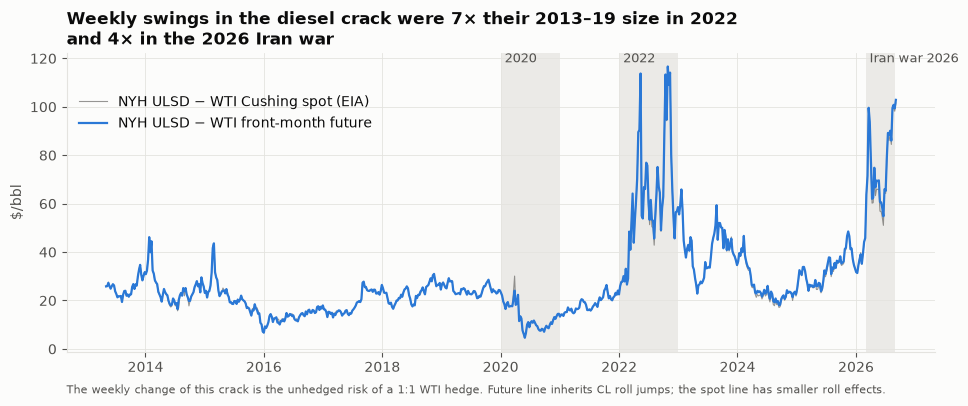

In [13]:
# Figure 1: the diesel crack. Its weekly change is exactly the basis of a 1:1 WTI hedge.
crack = (px["nyh"] - px["cl"]).resample("W-FRI").last()
crack_spot = (px["nyh"] - px["wti_spot"]).resample("W-FRI").last()
dcrack = w["nyh"] - w["cl"]  # roll-cleaned weekly change of the crack
sd_crack = {n: dcrack.loc[a:b].std() for n, a, b in REGIMES}
display(pd.Series(sd_crack, name="sd of weekly crack change, $/bbl").round(2))
ratio22 = sd_crack["2022"] / sd_crack["2013-19"]
ratio_iran = sd_crack["Iran war 2026"] / sd_crack["2013-19"]

fig, ax = plt.subplots(figsize=(10, 4.2))
for n, a, b in STRESS:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=GRID, alpha=0.7, lw=0)
    ax.text(pd.Timestamp(a), 1.0, f" {n}", transform=ax.get_xaxis_transform(), va="top", color=INK2, fontsize=9)
ax.plot(crack_spot.index, crack_spot, color=INK2, lw=0.8, alpha=0.6, label="NYH ULSD − WTI Cushing spot (EIA)")
ax.plot(crack.index, crack, color=HO_C, lw=1.6, label="NYH ULSD − WTI front-month future")
ax.set_ylabel("$/bbl")
ax.set_title(f"Weekly swings in the diesel crack were {ratio22:.0f}× their 2013–19 size in 2022\n"
             f"and {ratio_iran:.0f}× in the 2026 Iran war")
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.9))
ax.text(0, -0.14, "The weekly change of this crack is the unhedged risk of a 1:1 WTI hedge. Future line inherits CL roll jumps; the spot line has smaller roll effects.",
        transform=ax.transAxes, color=INK2, fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "1_diesel_crack.png", dpi=150); plt.show()

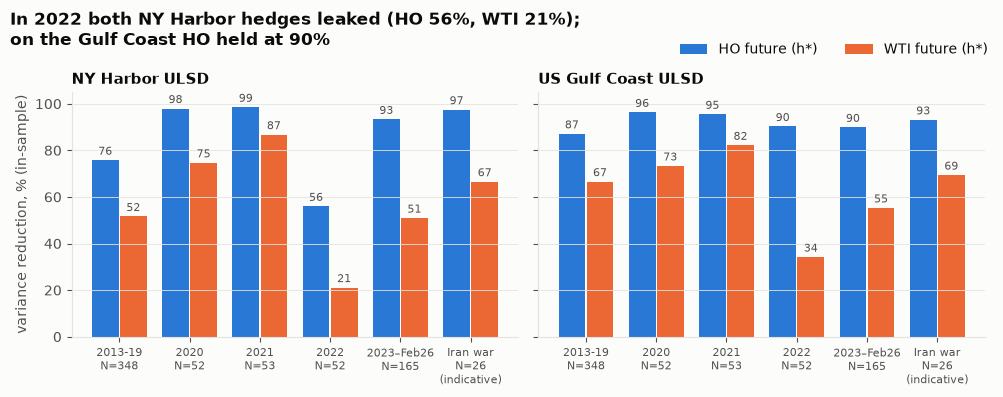

In [14]:
# Figure 2: in-sample effectiveness by regime, HO h* vs WTI h*, one panel per exposure.
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
x = np.arange(len(REGIMES)); bw = 0.38
for ax, (s, name) in zip(axes, [("nyh", "NY Harbor ULSD"), ("usgc", "US Gulf Coast ULSD")]):
    r = reg[s]
    b1 = ax.bar(x - bw / 2 - 0.01, r["HO h*"] * 100, bw, color=HO_C, label="HO future (h*)")
    b2 = ax.bar(x + bw / 2 + 0.01, r["WTI h*"] * 100, bw, color=WTI_C, label="WTI future (h*)")
    for bars in (b1, b2):
        ax.bar_label(bars, fmt="%.0f", fontsize=8, color=INK2, padding=2)
    ax.set_xticks(x, [n.replace("Iran war 2026", "Iran war").replace("2023-Feb 26", "2023–Feb26")
                      + f"\nN={int(r.loc[n, 'N'])}" + ("\n(indicative)" if n.startswith("Iran") else "")
                      for n, _, _ in REGIMES], fontsize=8)
    ax.set_title(name, fontsize=10.5); ax.set_ylim(0, 105); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("variance reduction, % (in-sample)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, bbox_to_anchor=(1, 0.93))
fig.suptitle(f"In 2022 both NY Harbor hedges leaked (HO {reg['nyh'].loc['2022','HO h*']*100:.0f}%, "
             f"WTI {reg['nyh'].loc['2022','WTI h*']*100:.0f}%);\non the Gulf Coast HO held at {reg['usgc'].loc['2022','HO h*']*100:.0f}%",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout(); fig.savefig(FIG / "2_effectiveness_by_regime.png", dpi=150); plt.show()

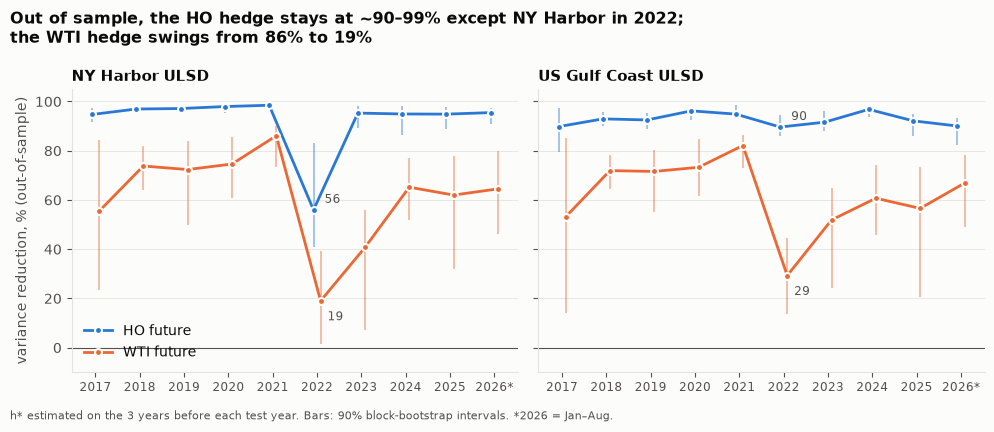

In [15]:
# Figure 3 (headline): out-of-sample effectiveness by year, with 90% block-bootstrap intervals.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, (s, name) in zip(axes, [("nyh", "NY Harbor ULSD"), ("usgc", "US Gulf Coast ULSD")]):
    for f, col, lab, dx in [("ho", HO_C, "HO future", -0.08), ("cl", WTI_C, "WTI future", 0.08)]:
        o = oos[(s, f)]
        yrs = o.index + dx
        ax.vlines(yrs, o["lo"] * 100, o["hi"] * 100, color=col, lw=1.2, alpha=0.5)
        ax.plot(yrs, o["eff"] * 100, color=col, lw=2, marker="o", ms=5, label=lab,
                markeredgecolor=SURF, markeredgewidth=1.5)
        ax.annotate(f"{o.loc[2022, 'eff']*100:.0f}", (2022 + dx, o.loc[2022, "eff"] * 100), xytext=(8, 5) if f == "ho" else (5, -14),
                    textcoords="offset points", color=INK2, fontsize=8.5)
    ax.axhline(0, color=INK2, lw=0.8)
    ax.set_title(name, fontsize=10.5); ax.set_xticks(list(OOS_YEARS), [str(y) if y < 2026 else "2026*" for y in OOS_YEARS], fontsize=8.5)
    ax.grid(axis="x", visible=False)
lo = min(o["lo"].min() for o in oos.values()) * 100
axes[0].set_ylim(min(-10, lo - 5), 105)
axes[0].set_ylabel("variance reduction, % (out-of-sample)")
axes[0].legend(loc="lower left")
wti = pd.concat([oos[(k, "cl")]["eff"] for k in ["nyh", "usgc"]])
fig.suptitle(f"Out of sample, the HO hedge stays at ~90–99% except NY Harbor in 2022;\n"
             f"the WTI hedge swings from {wti.max()*100:.0f}% to {wti.min()*100:.0f}%",
             x=0.01, ha="left", fontweight="bold", fontsize=11.5)
fig.text(0.01, 0.005, "h* estimated on the 3 years before each test year. Bars: 90% block-bootstrap intervals. *2026 = Jan–Aug.",
         color=INK2, fontsize=8)
fig.tight_layout(rect=(0, 0.03, 1, 1)); fig.savefig(FIG / "3_out_of_sample.png", dpi=150); plt.show()

In [16]:
# Reference values quoted in the key results and the README: warn if a re-download moves them.
import warnings
REF = {("nyh", "ho", 2022): 0.560, ("nyh", "cl", 2022): 0.190, ("usgc", "ho", 2022): 0.896, ("usgc", "cl", 2022): 0.293,
       ("nyh", "cl", 2020): 0.746, ("usgc", "cl", 2020): 0.733}
for (sx, f, y), v in REF.items():
    got = oos[(sx, f)].loc[y, "eff"]
    if abs(got - v) > 0.01:
        warnings.warn(f"{sx}/{f} {y}: {got:.3f} vs reference {v:.3f} - update the README")
ho_min = min(oos[(sx, "ho")]["eff"].drop(2022 if sx == "nyh" else []).min() for sx in ["nyh", "usgc"])
print(f"HO out-of-sample min (excl. NYH 2022): {ho_min:.3f}; "
      f"WTI ranges: NYH {oos[('nyh','cl')]['eff'].min():.2f}-{oos[('nyh','cl')]['eff'].max():.2f}, "
      f"USGC {oos[('usgc','cl')]['eff'].min():.2f}-{oos[('usgc','cl')]['eff'].max():.2f}")

HO out-of-sample min (excl. NYH 2022): 0.896; WTI ranges: NYH 0.19-0.86, USGC 0.29-0.82


## 7. Market context

Timing matches, not proven causes: the project has no inventory or flow data.

- **2014–15, NY Harbor basis** (sd of weekly NYH − HO: 2.72 and 2.18 \$/bbl vs 0.40 in 2013; weeks of 12.8 on 2014-02-14 and 13.5 on 2015-03-06).
  Both coincide with cold East Coast winters, with Mid-Atlantic distillate stocks at ten-year lows in early February 2014
  ([NYSERDA, 2014-02-10](https://www.nyserda.ny.gov/-/media/Project/Nyserda/Files/EDPPP/Energy-Prices/Current-Outlook/2014-02-10-Heating-Fuels-Report.pdf)):
  consistent with a local, seasonal squeeze that HO only partly tracks.
- **2020** (out of sample: NYH HO 0.98, WTI 0.75). The May WTI contract settled at −\$37.63 on 2020-04-20, an expiry and Cushing-storage event
  ([CRS](https://www.congress.gov/crs-product/IN11354)). The drop and the next day's rebound cancel within the week, and the NY Harbor basis stayed calm, consistent with the hedges holding.
- **2022** (NYH HO 0.56, WTI 0.19; USGC HO 0.90). In the project's EIA data the NYH − USGC spot spread reached \$1.40/gal on 12–13 May
  and again on 10 November 2022, coinciding with the 25.4 and 48.4 \$/bbl basis weeks of 13 and 20 May; East Coast diesel inventories were then
  unusually tight ([FreightWaves, 2022-05-25](https://www.freightwaves.com/news/east-coast-diesel-inventories-tighter-again-other-numbers-offer-buyers-hope)). In October US distillate cover fell to 25 days, the lowest since 2008
  ([EIA, 2022-11-10](https://www.eia.gov/todayinenergy/detail.php?id=54619)), consistent with the Oct–Nov basis weeks (18.3, 19.2, 38.1).
- **2023** (WTI 0.41 NYH / 0.52 USGC, HO 0.95). The crack stayed more volatile than before 2020 (sd of weekly changes 3.18 \$/bbl over 2023–Feb 2026 vs 2.00 in 2013–19),
  coinciding with the re-routing of diesel trade around the EU ban on Russian products from 2023-02-05 ([NPR, 2023-02-03](https://www.npr.org/2023/02/03/1153833640/europe-russian-oil-products-ban)).
  WTI hedges the crude leg, not the diesel margin.
- **2026 Iran war** (in-sample NYH HO 0.975, WTI 0.665; crack sd 8.72). The war began on 28 February and the Strait of Hormuz closed on 4 March
  ([Wikipedia](https://en.wikipedia.org/wiki/Economic_impact_of_the_2026_Iran_war)). WTI ended the week of 6 March at \$90.90, up more than 35%
  ([Wikipedia](https://en.wikipedia.org/wiki/2026%E2%80%93present_world_oil_market_chronology)), coinciding with the large daily basis gaps of 9–10 March.
  The EIA saw US retail diesel peaking above \$5.80/gal in April ([EIA, 2026-04-07](https://www.eia.gov/pressroom/releases/press586.php)).
  Unlike 2022, HO held (0.975 / 0.93) and WTI stayed in its usual range (0.665 / 0.69): consistent with a shock that moved crude and diesel together,
  not a local diesel squeeze.

**What the numbers do not show.** Variance reduction ignores the *level* of the basis, roll costs and margin calls (a well-scored hedge can still lose money
or strain liquidity, as in 2022). The Iran-war figures rest on 26 weeks. The 2026 sources are secondary (Wikipedia) apart from the EIA.

## 8. Limits

- **Rolls.** Dropping roll-day changes also removes ~10% of days of genuine spot risk, whose hedged P&L we cannot observe
  without individual contract prices. The kept series still holds the last, illiquid days of the expiring contract, whereas a real hedger rolls earlier.
  In the week of 20 April 2020 the series follows the May contract to its expiry and the June contract afterwards. Raw Friday changes are shown as a sensitivity.
- **Prices.** Yahoo closes are close to, not identical to, NYMEX settlements; EIA spot assessments are end-of-day. Weekly sampling limits the timing mismatch.
- **Small samples.** 2020–2022 are ~52 weeks each, the Iran-war regime ~26 weeks: a variance ratio on so few weeks is noisy. Intervals are shown;
  overlapping intervals are read as "no clear difference" (a reading rule, not a formal test).
- **Concentration.** The NY Harbor HO failure in 2022 comes from a few squeeze weeks (see section 5); the WTI failure does not.
- **Dollar changes.** Changes are in \$/bbl, not %, so volatility scales with the price level: high-price years (2022, 2026)
  weigh most in full-sample numbers, and "7× the 2013–19 swings" partly reflects a higher price level (sd of ΔNYH itself rose from ~2.5 to 16.5 \$/bbl).
- **Choices made after a first look.** Splitting 2021 and 2022 was decided after a preliminary out-of-sample pass. The roll treatment was chosen after a first pass on the data showed the roll artefact; it is justified on
  mechanical grounds (a hedger does not bear the contract switch), and the raw specification stays visible.
- **Sample start.** May 2013: the HO contract became ULSD with the May 2013 contract; earlier data would mix in a quality (sulphur) basis.